# 06 — Unconstrained minimization

Three optimizers from `numethods.optimization`:

- **gradient_descent** – fixed step (with optional momentum).
- **gradient_descent_backtracking** – Armijo line search makes step
   selection automatic.
- **newton_minimize** – quadratic convergence with second-derivative info.

Test problem: the Rosenbrock banana, with optimum at $(1, 1)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (7, 4.5), "figure.dpi": 110, "axes.grid": True})

from numethods import (
    gradient_descent, gradient_descent_backtracking, newton_minimize,
)


## Three optimizers on Rosenbrock

In [2]:
def f(x): return (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2
def g(x): return np.array([
    -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2),
     200*(x[1] - x[0]**2),
])
def H(x): return np.array([
    [2 - 400*(x[1] - 3*x[0]**2), -400*x[0]],
    [-400*x[0], 200],
])

x0 = np.array([-1.2, 1.0])
gd = gradient_descent_backtracking(f, g, x0, tol=1e-6, max_iter=20_000)
nw = newton_minimize(f, g, H, x0, tol=1e-10)
print(f'backtracking GD : x={gd.x}, iters={gd.iterations}')
print(f'newton          : x={nw.x}, iters={nw.iterations}')


backtracking GD : x=[0.99999922 0.99999843], iters=13756
newton          : x=[1. 1.], iters=7


## Trajectories overlaid on the contour plot

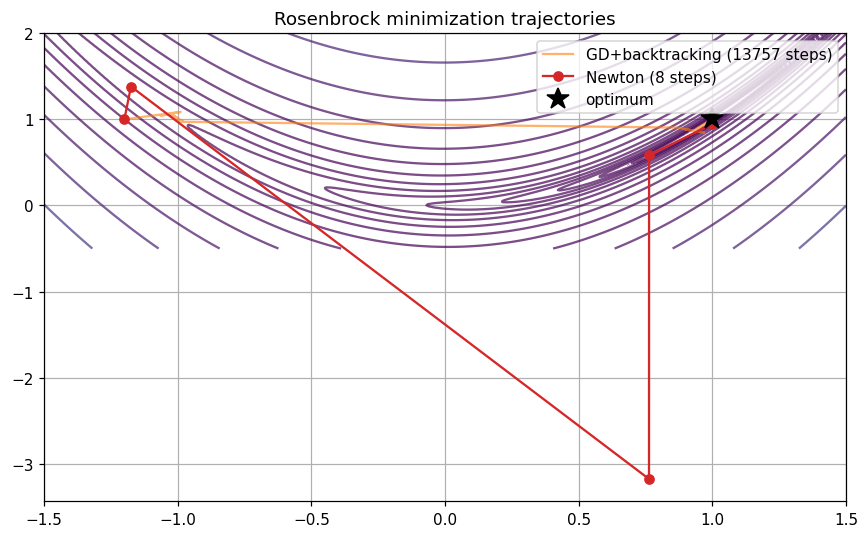

In [3]:
xs = np.linspace(-1.5, 1.5, 200)
ys = np.linspace(-0.5, 2.0, 200)
X, Y = np.meshgrid(xs, ys)
Z = (1 - X)**2 + 100*(Y - X**2)**2

fig, ax = plt.subplots(figsize=(8, 5))
levels = np.logspace(-1, 3.5, 18)
ax.contour(X, Y, Z, levels=levels, cmap='viridis', alpha=0.7)

gd_path = np.array(gd.history)
nw_path = np.array(nw.history)
ax.plot(gd_path[:, 0], gd_path[:, 1], '-', color='C1',
        label=f'GD+backtracking ({len(gd_path)} steps)', alpha=0.6)
ax.plot(nw_path[:, 0], nw_path[:, 1], 'o-', color='C3',
        label=f'Newton ({len(nw_path)} steps)')
ax.plot(1, 1, 'k*', markersize=15, label='optimum')
ax.legend(); ax.set_title('Rosenbrock minimization trajectories')
fig.tight_layout(); plt.show()


Newton dives directly toward the bottom; gradient descent has to follow the curving valley. This notebook demonstrates `numethods.optimization`.